# Authenticity

In [ ]:
!pip install pandas tqdm openai tenacity

In [ ]:
import pandas as pd
from tqdm import tqdm
import json
import os
from openai import OpenAI
from tenacity import retry, stop_after_attempt, wait_exponential

df = pd.read_csv("dei_tweets_merged.csv")

df = df.dropna(subset=["text"])
df = df.reset_index(drop=True)

print(df.shape)
df.head()

## LLM as a judge

In [ ]:
SYSTEM_PROMPT = """You are an expert social scientist analysing political and social discourse on Twitter.
You are precise, cautious, and avoid overconfidence.
"""

USER_PROMPT_TEMPLATE = """
Analyse the following tweet about Diversity, Equity, and Inclusion (DEI).

Tweet:
"{tweet}"

Task:
Evaluate whether the tweet expresses *genuine, authentic motivation* or is more likely *performative, ironic, opportunistic, or engagement-driven*.

Use the following scale:
0 = clearly performative / ironic / cynical
1 = mostly performative
2 = mixed or unclear motivation
3 = mostly genuine
4 = clearly genuine and authentic

Return your answer in JSON with:
- "score": integer from 0 to 4
- "reasoning": brief explanation (2–4 sentences)
"""

from openai import OpenAI
from tenacity import retry, stop_after_attempt, wait_exponential

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

@retry(wait=wait_exponential(min=1, max=60), stop=stop_after_attempt(5))
def score_tweet(tweet_text):
    response = client.chat.completions.create(
        model="gpt-4.1-mini",  # strong + cost-effective judge
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": USER_PROMPT_TEMPLATE.format(tweet=tweet_text)
            }
        ]
    )

    content = response.choices[0].message.content
    return json.loads(content)

results = []

for tweet in tqdm(df["text"], total=len(df)):
    try:
        res = score_tweet(tweet)
        results.append(res)
    except Exception as e:
        results.append({"score": None, "reasoning": str(e)})

df["authenticity_score"] = [r["score"] for r in results]
df["authenticity_reasoning"] = [r["reasoning"] for r in results]

df.head()

df["authenticity_score"].value_counts().sort_index()

df.groupby("authenticity_score").sample(
    n=3, random_state=42
)[["text", "authenticity_reasoning"]]

def label_authenticity(score):
    if score <= 1:
        return "Performative"
    elif score == 2:
        return "Ambiguous"
    else:
        return "Genuine"

df["authenticity_label"] = df["authenticity_score"].apply(label_authenticity)

## BERT

In [ ]:
 !pip install sentence-transformers scikit-learn pandas tqdm matplotlib

In [7]:
from sentence_transformers import SentenceTransformer
import pandas as pd

df = pd.read_csv("dei_tweets_merged.csv")
df = df.dropna(subset=["text"])
df = df.reset_index(drop=True)


model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

authenticity_anchors = {
    0: "This tweet expresses cynical, ironic, or purely performative support for DEI.",
    1: "This tweet supports DEI mainly for appearance, branding, or engagement.",
    2: "This tweet shows mixed or unclear motivation about DEI.",
    3: "This tweet expresses mostly genuine concern and belief in DEI.",
    4: "This tweet expresses clearly genuine, authentic commitment to DEI."
}

anchor_texts = list(authenticity_anchors.values())
anchor_embeddings = model.encode(anchor_texts, normalize_embeddings=True)

from tqdm import tqdm

print(f"Encoding {len(df)} tweets...")

tweet_embeddings = model.encode(
    df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Tweet embeddings completed.")


import numpy as np

similarities = np.dot(tweet_embeddings, anchor_embeddings.T)

df["authenticity_score"] = similarities.argmax(axis=1)

weighted_scores = np.sum(
    similarities * np.arange(5),
    axis=1
) / similarities.sum(axis=1)

df["authenticity_score_continuous"] = weighted_scores

def label_authenticity(score):
    if score <= 1:
        return "Performative"
    elif score < 3:
        return "Ambiguous"
    else:
        return "Genuine"

df["authenticity_label"] = df["authenticity_score_continuous"].apply(label_authenticity)


Encoding 2026 tweets...


Batches: 100%|██████████| 32/32 [00:04<00:00,  6.56it/s]

Tweet embeddings completed.


## Visualisation

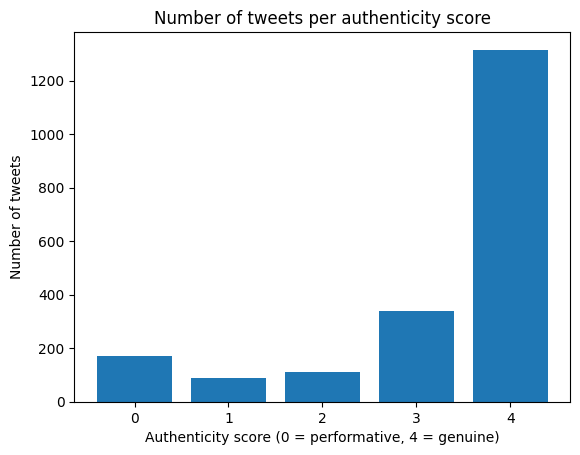

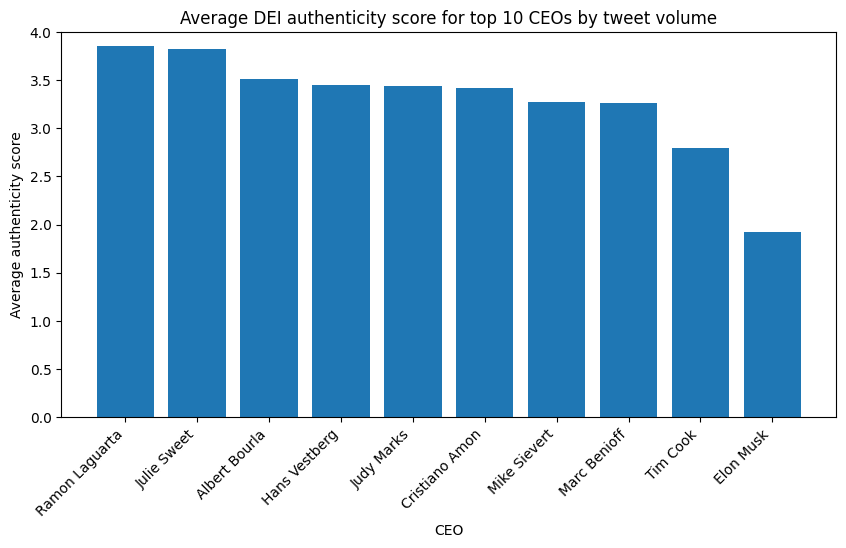

In [8]:
import matplotlib.pyplot as plt

score_counts = (
    df["authenticity_score"]
    .value_counts()
    .sort_index()
)

plt.figure()
plt.bar(score_counts.index, score_counts.values)
plt.xlabel("Authenticity score (0 = performative, 4 = genuine)")
plt.ylabel("Number of tweets")
plt.title("Number of tweets per authenticity score")
plt.xticks(score_counts.index)
plt.show()

top_10_ceos = (
    df["CEO"]
    .value_counts()
    .head(10)
    .index
)
ceo_avg_scores = (
    df[df["CEO"].isin(top_10_ceos)]
    .groupby("CEO")["authenticity_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(ceo_avg_scores.index, ceo_avg_scores.values)
plt.xlabel("CEO")
plt.ylabel("Average authenticity score")
plt.title("Average DEI authenticity score for top 10 CEOs by tweet volume")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 4)
plt.show()



/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8r0000gr/T/ipykernel_72152/590101274.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()


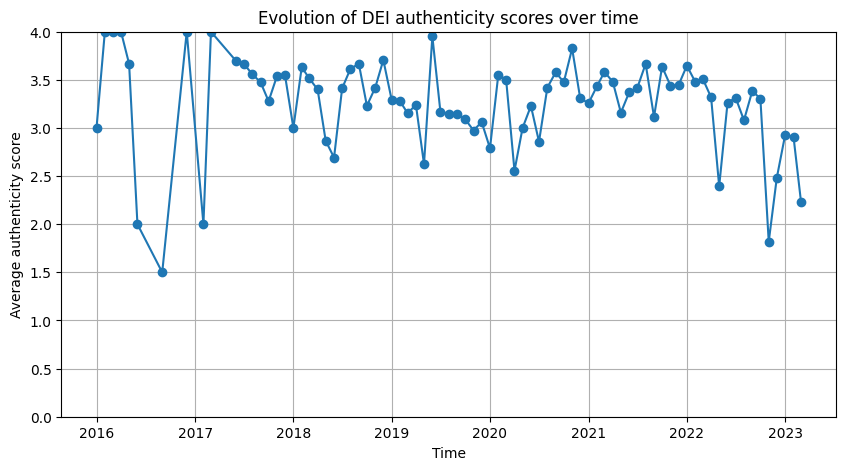

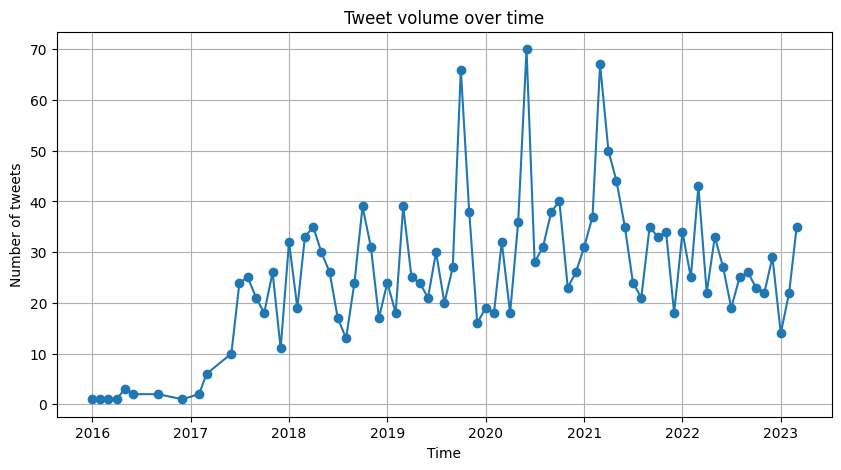

In [9]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

df = df.dropna(subset=["created_at", "authenticity_score"])
df = df.sort_values("created_at")

df["month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()

monthly_scores = (
    df.groupby("month")["authenticity_score"]
    .mean()
)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(monthly_scores.index, monthly_scores.values, marker="o")
plt.xlabel("Time")
plt.ylabel("Average authenticity score")
plt.title("Evolution of DEI authenticity scores over time")
plt.ylim(0, 4)
plt.grid(True)
plt.show()

monthly_counts = df.groupby("month").size()
plt.figure(figsize=(10, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker="o")
plt.xlabel("Time")
plt.ylabel("Number of tweets")
plt.title("Tweet volume over time")
plt.grid(True)
plt.show()


Number of CEOs: 35


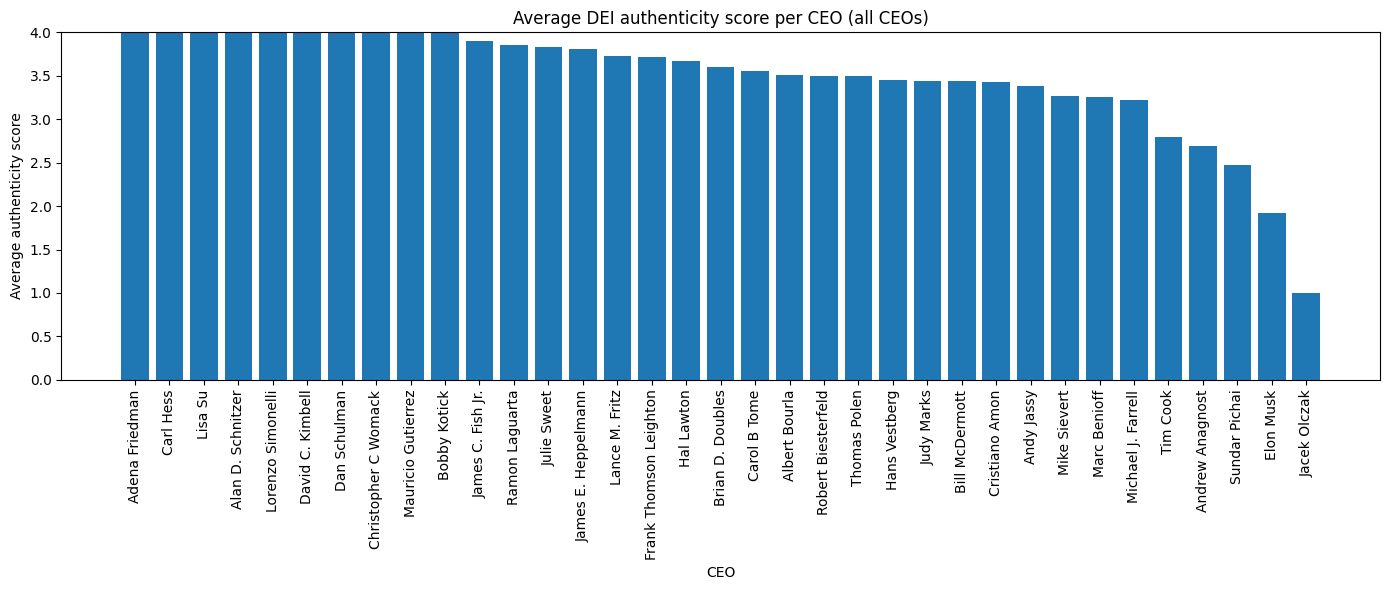

In [10]:
import matplotlib.pyplot as plt

# Compute average authenticity score per CEO
ceo_avg_scores = (
    df.dropna(subset=["CEO", "authenticity_score"])
      .groupby("CEO")["authenticity_score"]
      .mean()
      .sort_values(ascending=False)
)

print(f"Number of CEOs: {len(ceo_avg_scores)}")

# Plot
plt.figure(figsize=(14, 6))
plt.bar(ceo_avg_scores.index, ceo_avg_scores.values)
plt.xlabel("CEO")
plt.ylabel("Average authenticity score")
plt.title("Average DEI authenticity score per CEO (all CEOs)")
plt.ylim(0, 4)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


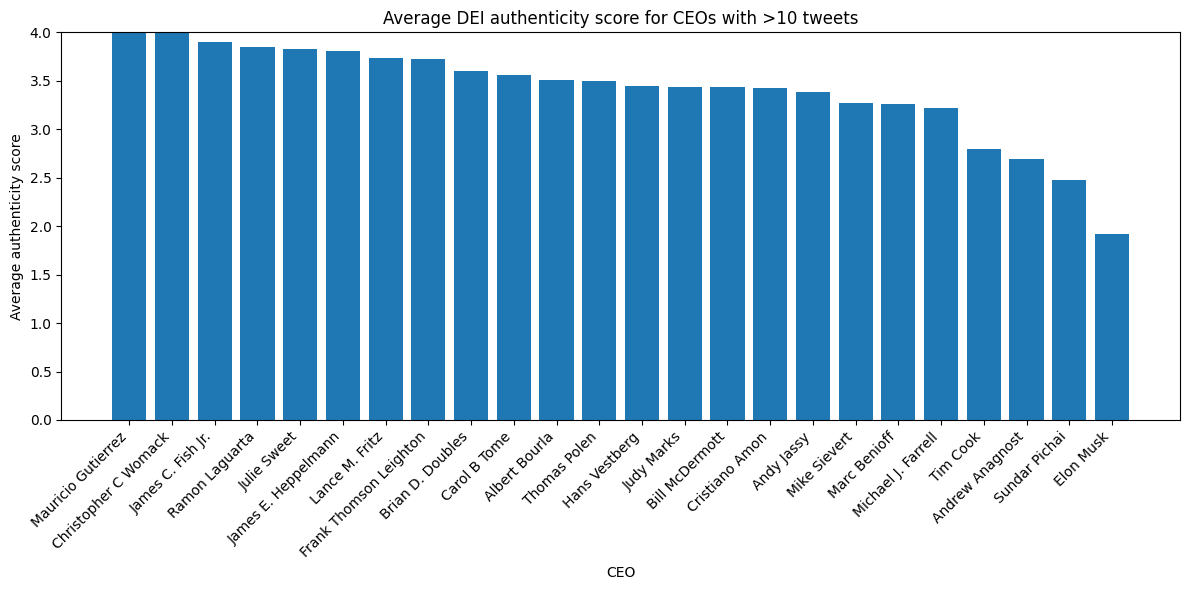

In [12]:
import matplotlib.pyplot as plt

# Count tweets per CEO
ceo_counts = df["CEO"].value_counts()

# Filter CEOs with more than 10 tweets
ceos_10plus = ceo_counts[ceo_counts > 10].index

# Compute average authenticity score for these CEOs
ceo_avg_scores_10plus = (
    df[df["CEO"].isin(ceos_10plus)]
      .groupby("CEO")["authenticity_score"]
      .mean()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(ceo_avg_scores_10plus.index, ceo_avg_scores_10plus.values)
plt.xlabel("CEO")
plt.ylabel("Average authenticity score")
plt.title("Average DEI authenticity score for CEOs with >10 tweets")
plt.ylim(0, 4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# Filter tweets with score 0
tweets_score_0 = df[df["authenticity_score"] == 0]

# Sample 3 random tweets (or fewer if less than 3 exist)
sample_0 = tweets_score_0.sample(n=min(3, len(tweets_score_0)), random_state=66)

# Print
for i, row in sample_0.iterrows():
     print(f"Tweet {i}:\n{row['text']}\nScore: {row['authenticity_score']}\n{'-'*80}")


Tweet 232:
MuskUniversity So many guys who got MeTooed went woke for the moral cloak
Score: 0
--------------------------------------------------------------------------------
Tweet 745:
Everyone has a right to freedom & equality. Proud of Google's support for the LGBTQ community #prideforeveryone
Score: 0
--------------------------------------------------------------------------------
Tweet 532:
We think deeply about how our products can enrich rather than restrict and connect rather than isolate. Our technology is built intentionally by listening and developing new paths to an accessible, inclusive future for all. GAAD
Score: 0
--------------------------------------------------------------------------------
